In [1]:
import numpy as np
import torch
from datasets import load_dataset
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

/home/mushu-cislab/GitHub/RandomThings/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("microsoft/cats_vs_dogs", split="train")
print(dataset)

Dataset({
    features: ['image', 'labels'],
    num_rows: 23410
})


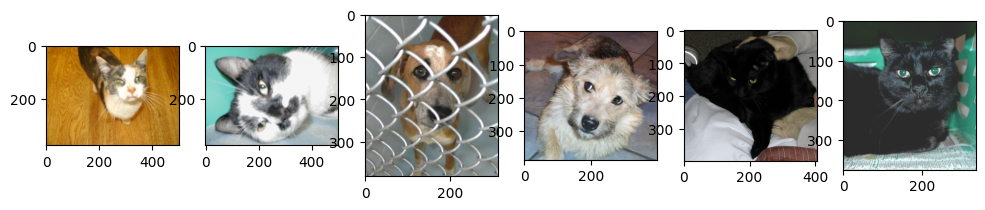

In [3]:
label_names = ["cat", "dog"]
plt.figure(figsize=(12, 4))

for i in range(6):
  idx = random.randint(0, len(dataset) - 1)
  sample = dataset[idx]
  image = sample["image"]
  label = sample["labels"]

  # label is either 0 or 1
  plt.subplot(1, 6, i+1)
  plt.imshow(image)


In [4]:
IMAGE_SIZE = 64

class ImageDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.transform = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0,0,0], std=[1,1,1])
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item["image"]

        if image.mode != "RGB":
            image = image.convert("RGB")

        image = self.transform(image)
        label = torch.tensor(item["labels"], dtype=torch.long)

        return image, label

In [5]:
dataset = load_dataset("microsoft/cats_vs_dogs", split="train")

dataset = dataset.shuffle(seed=42)
split = int(0.8 * len(dataset))

train_ds = dataset.select(range(split))
test_ds = dataset.select(range(split, len(dataset)))

In [6]:
from PIL import Image



train_dataset = ImageDataset(train_ds)
test_dataset = ImageDataset(test_ds)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256)

In [18]:
class ModelA(nn.Module):
    def __init__(self,in_channels, num_classes, hidden_dim):
        super(ModelA, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=7),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class ModelB(nn.Module):
    def __init__(self,in_channels, num_classes, hidden_dim):
        super(ModelB, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=7),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class ModelC(nn.Module):
    def __init__(self,in_channels, num_classes, hidden_dim):
        super(ModelC, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=3),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=4),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=6),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=7),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=6),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=4),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class ModelD(nn.Module):
    def __init__(self, in_channels, num_classes, hidden_dim):
        super(ModelD, self).__init__()
        # Keep width the same as other models, but reduce activation memory early.
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(),

            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=5, padding=2),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(),

            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU(),

            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
def train_epoch(model, loader, optimizer, creiterion, device):
    model.train()
    total_loss = 0
    total_correct = 0
    n = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = creiterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == labels).sum().item()

        n += images.size(0)   # FIXED

    avg_loss = total_loss / n
    acc = total_correct / n

    return avg_loss, acc

In [9]:
def eval_epoch(model, loader, creiterion, device):
    model.eval()
    total_loss = 0
    total_correct = 0
    n = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            loss = creiterion(logits, labels)

            total_loss += loss.item() * images.size(0)

            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()

            n += images.size(0)

    avg_loss = total_loss / n
    acc = total_correct / n

    return avg_loss, acc

In [10]:
@torch.no_grad()
def test_epoch(model, loader, creiterion, device):
  total_loss= 0.0
  total_correct = 0
  n = 0

  for images, labels in loader:
    images = images.to(device)
    labels = labels.to(device)


    logits = model(images)
    loss = creiterion(logits, labels)



    total_loss += loss.item() * images.size(0)
    preds = torch.argmax(logits, dim=1)
    total_correct += (preds == labels).sum().item()
    n += images.size(0)

  avg_loss = total_loss / n
  avg_acc = total_correct / n
  return avg_loss, avg_acc

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_layers = 7
hidden_dim = 150
input_dim = IMAGE_SIZE * IMAGE_SIZE * 3
num_class = 2
epochs = 7
learning_rate = 1e-5
channels = 3

def train_model(model: torch.nn, model_name: str, train_loader_override=None, eval_loader_override=None):
  model.to(device)
  print(f"number of params: {sum(p.numel() for p in model.parameters())}")
  optimier = torch.optim.Adam(model.parameters(), lr=learning_rate)
  creiterion = nn.CrossEntropyLoss()

  local_train_loader = train_loader_override if train_loader_override is not None else train_loader
  local_eval_loader = eval_loader_override if eval_loader_override is not None else test_loader

  history = {
      "train_loss": [],
      "eval_loss": [],
      "train_acc": [],
      "eval_acc": []
  }

  for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, local_train_loader, optimier, creiterion, device)
    eval_loss, eval_acc = eval_epoch(model, local_eval_loader, creiterion, device)

    history["train_loss"].append(train_loss)
    history["eval_loss"].append(eval_loss)
    history["train_acc"].append(train_acc)
    history["eval_acc"].append(eval_acc)

    print(
      f"{model_name} | epoch:{epoch + 1}/{epochs}, "
      f"train_loss:{train_loss:.4f}, train_acc:{train_acc:.4f}, "
      f"eval_loss:{eval_loss:.4f}, eval_acc:{eval_acc:.4f}"
    )

  test_loss, test_acc = test_epoch(model, local_eval_loader, creiterion, device)
  print(f"{model_name} final test_loss:{test_loss:.4f}, test_acc:{test_acc:.4f}")
  return history

In [12]:
model_a = ModelA(channels, num_class, hidden_dim)
history_a = train_model(model_a, "Model A")

number of params: 22502
Model A | epoch:1/7, train_loss:0.6960, train_acc:0.4978, eval_loss:0.6940, eval_acc:0.5021
Model A | epoch:2/7, train_loss:0.6939, train_acc:0.4970, eval_loss:0.6936, eval_acc:0.5030
Model A | epoch:3/7, train_loss:0.6936, train_acc:0.5022, eval_loss:0.6935, eval_acc:0.4906
Model A | epoch:4/7, train_loss:0.6934, train_acc:0.5007, eval_loss:0.6934, eval_acc:0.4930
Model A | epoch:5/7, train_loss:0.6932, train_acc:0.5035, eval_loss:0.6932, eval_acc:0.5045
Model A | epoch:6/7, train_loss:0.6931, train_acc:0.5073, eval_loss:0.6930, eval_acc:0.5085
Model A | epoch:7/7, train_loss:0.6930, train_acc:0.5091, eval_loss:0.6929, eval_acc:0.5117
Model A final test_loss:0.6929, test_acc:0.5117


In [13]:
model_b = ModelB(channels, num_class, hidden_dim)
history_b = train_model(model_b, "Model B")

number of params: 1512452
Model B | epoch:1/7, train_loss:0.6933, train_acc:0.5016, eval_loss:0.6918, eval_acc:0.5179
Model B | epoch:2/7, train_loss:0.6898, train_acc:0.5343, eval_loss:0.6874, eval_acc:0.5389
Model B | epoch:3/7, train_loss:0.6836, train_acc:0.5567, eval_loss:0.6808, eval_acc:0.5675
Model B | epoch:4/7, train_loss:0.6776, train_acc:0.5766, eval_loss:0.6767, eval_acc:0.5771
Model B | epoch:5/7, train_loss:0.6722, train_acc:0.5858, eval_loss:0.6691, eval_acc:0.5980
Model B | epoch:6/7, train_loss:0.6681, train_acc:0.5903, eval_loss:0.6658, eval_acc:0.6000
Model B | epoch:7/7, train_loss:0.6635, train_acc:0.6023, eval_loss:0.6584, eval_acc:0.6134
Model B final test_loss:0.6584, test_acc:0.6134


In [19]:
# Smaller batch sizes for Model D to avoid CUDA OOM
train_loader_d = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader_d = DataLoader(test_dataset, batch_size=32)

if torch.cuda.is_available():
    torch.cuda.empty_cache()

model_d = ModelD(channels, num_class, hidden_dim)
history_d = train_model(model_d, "Model D", train_loader_d, test_loader_d)

number of params: 1003502
Model D | epoch:1/7, train_loss:0.6415, train_acc:0.6370, eval_loss:0.6132, eval_acc:0.6741
Model D | epoch:2/7, train_loss:0.5897, train_acc:0.6984, eval_loss:0.5790, eval_acc:0.6848
Model D | epoch:3/7, train_loss:0.5411, train_acc:0.7346, eval_loss:0.5955, eval_acc:0.6719
Model D | epoch:4/7, train_loss:0.5060, train_acc:0.7582, eval_loss:0.6354, eval_acc:0.6548
Model D | epoch:5/7, train_loss:0.4727, train_acc:0.7811, eval_loss:0.4838, eval_acc:0.7587
Model D | epoch:6/7, train_loss:0.4532, train_acc:0.7930, eval_loss:0.4481, eval_acc:0.7939
Model D | epoch:7/7, train_loss:0.4307, train_acc:0.8062, eval_loss:0.4821, eval_acc:0.7636
Model D final test_loss:0.4821, test_acc:0.7636


In [17]:
model_c = ModelC(channels, num_class, hidden_dim)
history_c = train_model(model_c, "Model C")

number of params: 3650402
Model C | epoch:1/7, train_loss:0.6928, train_acc:0.5132, eval_loss:0.6915, eval_acc:0.5513
Model C | epoch:2/7, train_loss:0.6844, train_acc:0.5506, eval_loss:0.6771, eval_acc:0.5630
Model C | epoch:3/7, train_loss:0.6689, train_acc:0.5887, eval_loss:0.6616, eval_acc:0.6040
Model C | epoch:4/7, train_loss:0.6587, train_acc:0.6105, eval_loss:0.6521, eval_acc:0.6245
Model C | epoch:5/7, train_loss:0.6456, train_acc:0.6316, eval_loss:0.6573, eval_acc:0.5978
Model C | epoch:6/7, train_loss:0.6461, train_acc:0.6262, eval_loss:0.6291, eval_acc:0.6489
Model C | epoch:7/7, train_loss:0.6321, train_acc:0.6457, eval_loss:0.6368, eval_acc:0.6333
Model C final test_loss:0.6368, test_acc:0.6333


## Model A vs Model B vs Model C vs Model D Loss Curves
This graph overlays train and eval loss for all four models across epochs.

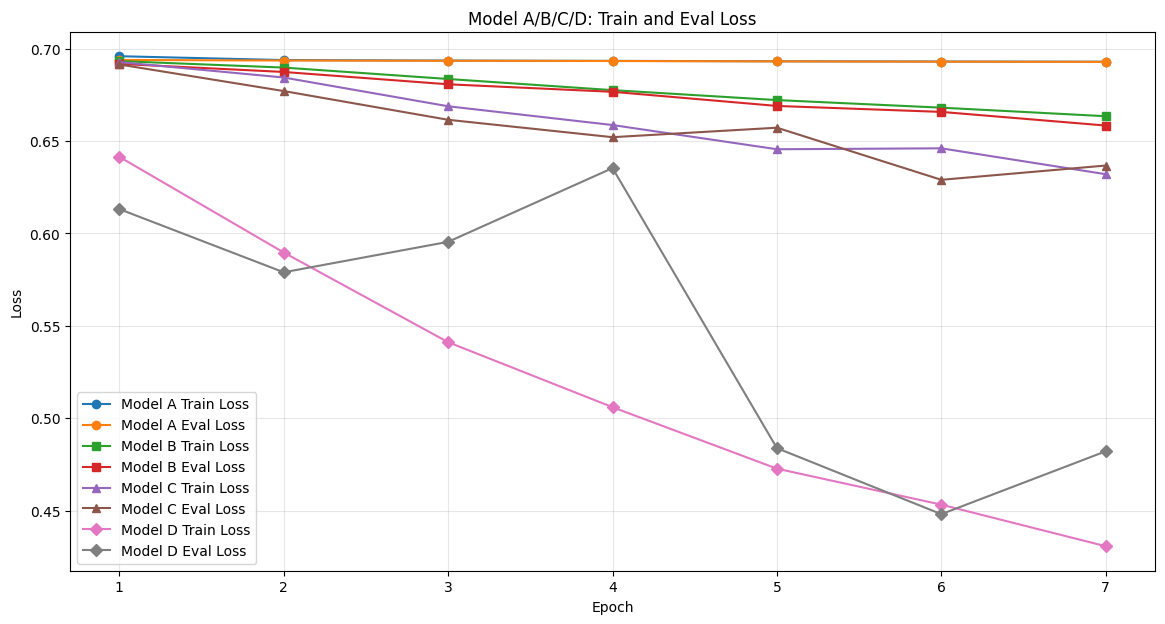

In [20]:
epochs_axis = range(1, epochs + 1)

plt.figure(figsize=(14, 7))
plt.plot(epochs_axis, history_a["train_loss"], label="Model A Train Loss", marker="o")
plt.plot(epochs_axis, history_a["eval_loss"], label="Model A Eval Loss", marker="o")
plt.plot(epochs_axis, history_b["train_loss"], label="Model B Train Loss", marker="s")
plt.plot(epochs_axis, history_b["eval_loss"], label="Model B Eval Loss", marker="s")
plt.plot(epochs_axis, history_c["train_loss"], label="Model C Train Loss", marker="^")
plt.plot(epochs_axis, history_c["eval_loss"], label="Model C Eval Loss", marker="^")
plt.plot(epochs_axis, history_d["train_loss"], label="Model D Train Loss", marker="D")
plt.plot(epochs_axis, history_d["eval_loss"], label="Model D Eval Loss", marker="D")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model A/B/C/D: Train and Eval Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [21]:
model_a.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model_a(images)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Final Test Accuracy: 0.5117


In [22]:
model_b.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model_b(images)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Final Test Accuracy: 0.6134


In [23]:
model_c.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model_c(images)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy_c = correct / total
print(f"Model C Final Test Accuracy: {test_accuracy_c:.4f}")

Model C Final Test Accuracy: 0.6333


In [24]:
model_d.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader_d:
        images = images.to(device)
        labels = labels.to(device)

        logits = model_d(images)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy_d = correct / total
print(f"Model D Final Test Accuracy: {test_accuracy_d:.4f}")

Model D Final Test Accuracy: 0.7636
